# <font color='blue'>FUMEC - Analytics com Python</font>
## **Lista de exercícios 11 - Classificação**

<br>**ATENÇÃO:** para salvar o arquivo .ipynb do notebook, faça da seguinte forma:

* **Google Colaboratory**: opção do menu "Arquivo --> Fazer download --> Baixar o .ipynb"

* Salve o arquivo com o nome "**SeuNome_lista10.ipynb**"

<br>



# **Classificação**

Explorar o problema da classificação, cusando um dataset com informações sobre a composição de vinhos, de acordo com dados abaixo:

<br>

**Link para o arquivo**

https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data

<br>

**Atributos**

0.  **Classe**: (1, 2, 3) - corresponde à categoria do vinho
1.  alcool
2.  acidez
3.  ash
4.  alcalinidade  
5.  magnesio
6.  fenois
7.  flavonoides
8.  fenois_nao_flav
9.  proantocianinas
10. cor
11. tonalidade
12. diluicao
13. proline



### **Importar as bibliotecas necessárias**

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

### **01) Carregar os dados do dataset `wine.data`**

In [2]:
# exercício 01 - <escrever o código neste bloco>

arquivo = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data'

cols = ['classe', 'alcool','acidez', 'ash', 'alcalinidade', 'magnesio', 'fenois', 'flavonoides', 'fenois_nao_flav', 'proantocianinas', 'cor', 'tonalidade', 'diluicao', 'proline' ]

df = pd.read_csv(arquivo, names=cols)
df.head(10)

,classe,alcool,acidez,ash,alcalinidade,magnesio,fenois,flavonoides,fenois_nao_flav,proantocianinas,cor,tonalidade,diluicao,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


### **02) Realizar a análise exploratória dos dados (use diversas análises)**


Fazer diversas análises exploratórias

In [3]:
print(df.shape)
print(df.info())

(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   classe           178 non-null    int64  
 1   alcool           178 non-null    float64
 2   acidez           178 non-null    float64
 3   ash              178 non-null    float64
 4   alcalinidade     178 non-null    float64
 5   magnesio         178 non-null    int64  
 6   fenois           178 non-null    float64
 7   flavonoides      178 non-null    float64
 8   fenois_nao_flav  178 non-null    float64
 9   proantocianinas  178 non-null    float64
 10  cor              178 non-null    float64
 11  tonalidade       178 non-null    float64
 12  diluicao         178 non-null    float64
 13  proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None


In [4]:
df.describe()

,classe,alcool,acidez,ash,alcalinidade,magnesio,fenois,flavonoides,fenois_nao_flav,proantocianinas,cor,tonalidade,diluicao,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
df.isnull().sum()

,0
classe,0
alcool,0
acidez,0
ash,0
alcalinidade,0
magnesio,0
fenois,0
flavonoides,0
fenois_nao_flav,0
proantocianinas,0


Ver a correlação entre os atributos

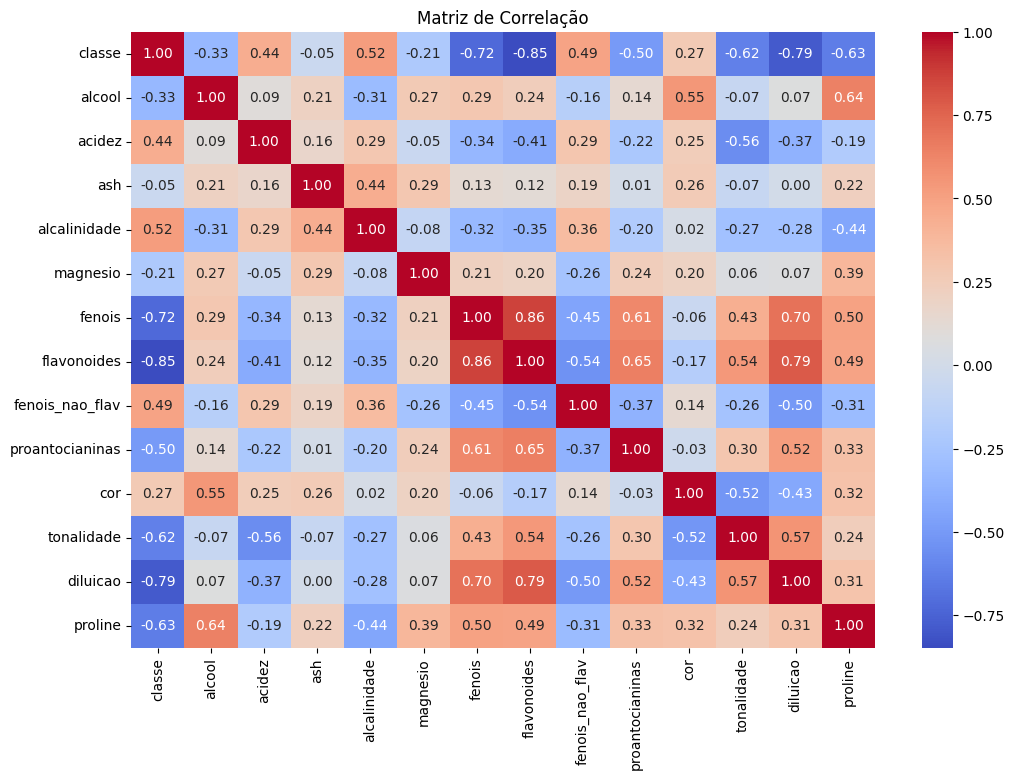

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

Ver a distribuiçãos dos valores da coluna 'classe' (alvo da classificação)

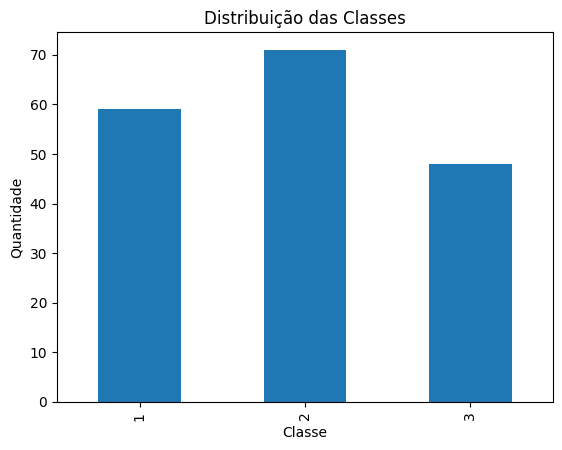

In [7]:
df['classe'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

Verificar existência de dados nulos

In [9]:
df.isnull().sum()

,0
classe,0
alcool,0
acidez,0
ash,0
alcalinidade,0
magnesio,0
fenois,0
flavonoides,0
fenois_nao_flav,0
proantocianinas,0


Identificar e excluir os outliers da coluna '**magnesio**'

In [11]:
Q1 = df['magnesio'].quantile(0.25)
Q3 = df['magnesio'].quantile(0.75)

IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df['magnesio'] < limite_inferior) |
    (df['magnesio'] > limite_superior)
]

print(outliers)

    classe  alcool  acidez   ash  alcalinidade  magnesio  fenois  flavonoides  \
69       2   12.21    1.19  1.75          16.8       151    1.85         1.28   
73       2   12.99    1.67  2.60          30.0       139    3.30         2.89   
78       2   12.33    0.99  1.95          14.8       136    1.90         1.85   
95       2   12.47    1.52  2.20          19.0       162    2.50         2.27   

    fenois_nao_flav  proantocianinas   cor  tonalidade  diluicao  proline  
69             0.14             2.50  2.85        1.28      3.07      718  
73             0.21             1.96  3.35        1.31      3.50      985  
78             0.35             2.76  3.40        1.06      2.31      750  
95             0.32             3.28  2.60        1.16      2.63      937  


In [15]:
df = df[
    (df['magnesio'] >= limite_inferior) &
    (df['magnesio'] <= limite_superior)
]

### **03) Preparar os dados, gerando os conjuntos de dados para treino e teste**


Separar as variáveis independentes X da variável alvo y (o atributo 'classe' será o alvo da classificação)

In [16]:
y = df['classe']
X = df.drop('classe', axis=1)

print(X.shape)
print(y.shape)

(174, 13)
(174,)


Padronizar as variáveis numéricas com o **StandardScaler**

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_padronizado = scaler.fit_transform(X)

Separar os conjuntos de treino e teste

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_padronizado,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
# conferindo a separação

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(139, 13)
(35, 13)
(139,)
(35,)


### **04) Treinamento e avaliação**

Você pode escolher qualquer método de classificação

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

Avaliação

In [21]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Acurácia:", acc)

Acurácia: 0.9428571428571428


Mostrar a matriz de confusão

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[16  0  0]
 [ 1  8  0]
 [ 0  1  9]]


Avaliar o resultado com outros classificadores

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

arvore = DecisionTreeClassifier(random_state=42)

arvore.fit(X_train, y_train)

y_pred_arvore = arvore.predict(X_test)

print("Acurácia Árvore:", accuracy_score(y_test, y_pred_arvore))
print(confusion_matrix(y_test, y_pred_arvore))

Acurácia Árvore: 0.9142857142857143
[[15  1  0]
 [ 2  7  0]
 [ 0  0 10]]


In [24]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Acurácia Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

Acurácia Naive Bayes: 0.9714285714285714
[[16  0  0]
 [ 1  8  0]
 [ 0  0 10]]


In [25]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Acurácia SVM:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

Acurácia SVM: 0.9714285714285714
[[16  0  0]
 [ 0  9  0]
 [ 0  1  9]]
